# Question 4

In [8]:
from collections import defaultdict
from scipy import stats
import numpy as np

In [2]:
# Calculate the probability that the sum of 2 dice equal 7

#List out all the pairs of possible outcome
d = { (i,j) : i + j for i in range(1,7) for j in range (1,7)}
# dictionary with key of two tuple and value i+j
print(d)

{(1, 1): 2, (1, 2): 3, (1, 3): 4, (1, 4): 5, (1, 5): 6, (1, 6): 7, (2, 1): 3, (2, 2): 4, (2, 3): 5, (2, 4): 6, (2, 5): 7, (2, 6): 8, (3, 1): 4, (3, 2): 5, (3, 3): 6, (3, 4): 7, (3, 5): 8, (3, 6): 9, (4, 1): 5, (4, 2): 6, (4, 3): 7, (4, 4): 8, (4, 5): 9, (4, 6): 10, (5, 1): 6, (5, 2): 7, (5, 3): 8, (5, 4): 9, (5, 5): 10, (5, 6): 11, (6, 1): 7, (6, 2): 8, (6, 3): 9, (6, 4): 10, (6, 5): 11, (6, 6): 12}


In [4]:
#invert the dictionary d
dinv = defaultdict(list)
for i,j in d.items(): dinv[j].append(i)
print(dinv)

defaultdict(<class 'list'>, {2: [(1, 1)], 3: [(1, 2), (2, 1)], 4: [(1, 3), (2, 2), (3, 1)], 5: [(1, 4), (2, 3), (3, 2), (4, 1)], 6: [(1, 5), (2, 4), (3, 3), (4, 2), (5, 1)], 7: [(1, 6), (2, 5), (3, 4), (4, 3), (5, 2), (6, 1)], 8: [(2, 6), (3, 5), (4, 4), (5, 3), (6, 2)], 9: [(3, 6), (4, 5), (5, 4), (6, 3)], 10: [(4, 6), (5, 5), (6, 4)], 11: [(5, 6), (6, 5)], 12: [(6, 6)]})


In [6]:
# dictionary X maps the sums to the probability of obtaining that sum
X = {i: len(j)/36 for i,j in dinv.items()}
print(X)

{2: 0.027777777777777776, 3: 0.05555555555555555, 4: 0.08333333333333333, 5: 0.1111111111111111, 6: 0.1388888888888889, 7: 0.16666666666666666, 8: 0.1388888888888889, 9: 0.1111111111111111, 10: 0.08333333333333333, 11: 0.05555555555555555, 12: 0.027777777777777776}


Alternative Solution:

In [9]:
# Create a list of tuples where [0]: a tuple (i,j) representing the two dice; [1]: sum of the two dice
pairs = [ ( (i,j) , i+j) for i in range(1,7) for j in range(1,7) ]
# create an np array of zero to store the number of times each possible sum occurs
occurrences_of_outcomes = np.zeros(12)
for pair in pairs:
    occurrences_of_outcomes[pair[1] - 1] += 1 #increment the value for appropriate index

print(occurrences_of_outcomes/ np.sum(occurrences_of_outcomes))


[0.         0.02777778 0.05555556 0.08333333 0.11111111 0.13888889
 0.16666667 0.13888889 0.11111111 0.08333333 0.05555556 0.02777778]


What is the probability that half the product of three dice will exceed their sum?

In [14]:
d = { (i,j,k) : ((i*j*k) > 2*(i+j+k)) for i in range(1,7) for j in range(1,7) for k in range(1,7)}
# create dictionary, mapping tuple of 3 dice to T/F values
dinv = defaultdict(list)
#inver the dictionary
for i, j in d.items(): dinv[j].append(i)

#create a new dictionary that maps T/F value into probability
X = {i: len(j)/6.0**3 for i,j in dinv.items()}
print(X)

#False <, True >

{False: 0.37037037037037035, True: 0.6296296296296297}


In [15]:
ans = [(i+j+k < (i*j*k)/2) for i in range(1,7) for j in range(1,7) for k in range(1,7)]
print(ans)
print(sum(ans)/len(ans))

[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, True, True, False, False, False, True, True, True, False, False, False, False, False, False, False, False, False, False, True, True, False, False, True, True, True, True, False, False, True, True, True, True, False, True, True, True, True, True, False, True, True, True, True, True, False, False, False, False, False, False, False, False, True, True, True, True, False, True, True, True, True, True, False, True, True, True, True, True, False, True, True, True, True, True, False, True, True, True, True, True, False, False, False, False, False, True, False, False, True, True, True, True, False, True, True, True, True, True, False, True, True, True, True, True, False, True, True, True, True, True, True, True, True, True, True, True, False, False, False, False, True, True, False, True, True, True, Tr

## Question 5

In [19]:
MU_VAL = 30
SIGMA_VAL = 1.8
lower_val = stats.norm.cdf(28, MU_VAL, SIGMA_VAL) # P[X < 28]
upper_val = stats.norm.cdf(33, MU_VAL, SIGMA_VAL) # P[X < 33]
print(upper_val)
print(lower_val)
print("Actual value: {}".format(upper_val-lower_val))

0.9522096477271853
0.13326026290250537
Actual value: 0.8189493848246799


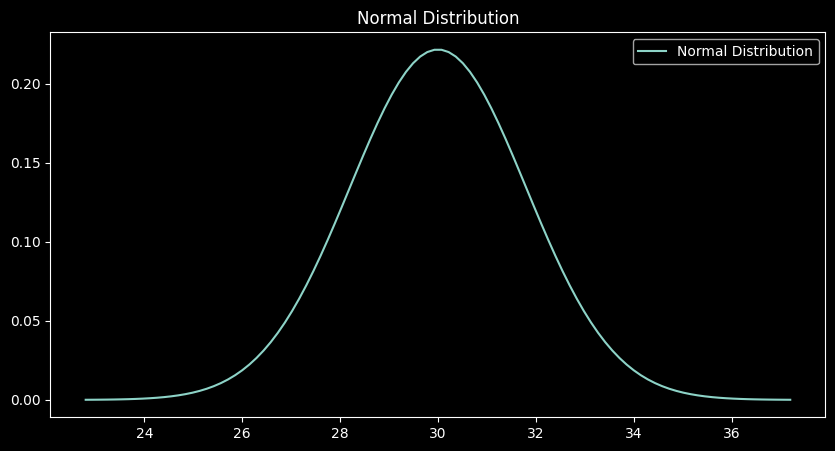

In [20]:
import matplotlib.pyplot as plt

x = np.linspace(MU_VAL-4*SIGMA_VAL, MU_VAL+4*SIGMA_VAL, 100)
y = stats.norm.pdf(x, loc = MU_VAL, scale = SIGMA_VAL)

plt.figure(figsize=(10,5))
plt.plot(x, y, label="Normal Distribution")
plt.title("Normal Distribution")
plt.legend()
plt.show()


## Question 10 and 11

In [ ]:
matrix_a = np.array([
    [1,2],
    [3,4]
])
rank_a = np.linalg.matrix_rank(matrix_a)
print(rank_a)

In [22]:
matrix_b = np.array([
    [1,2,3],
    [4,5,6],
    [7,8,9]
])
rank_b = np.linalg.matrix_rank(matrix_b)
print(rank_b)

2
